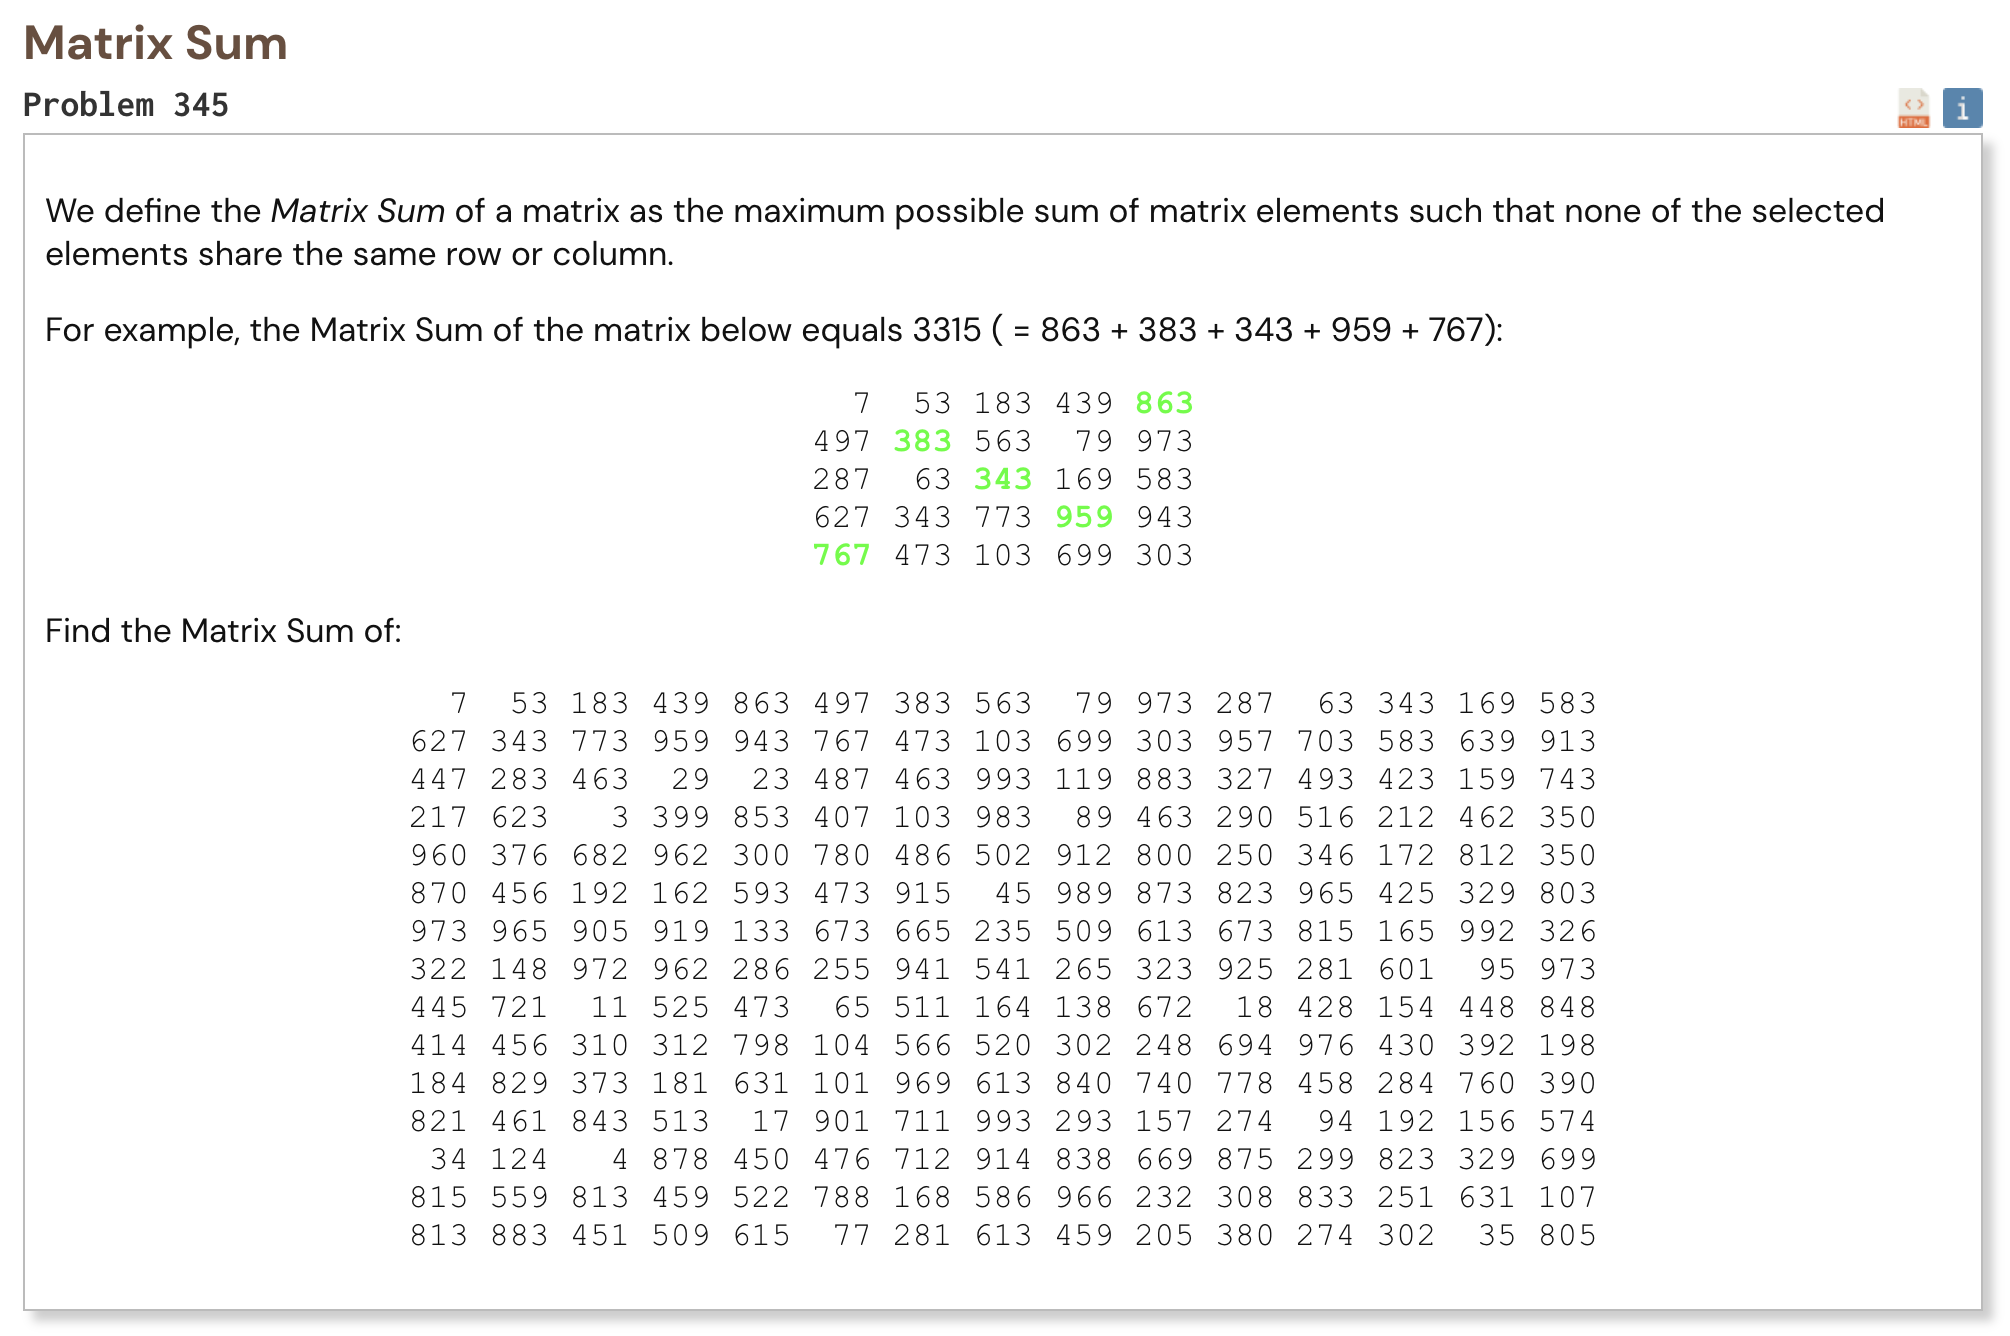

## Initial approach

* this is a classic assignment problem
* choose exactly one number from every row
* also use every column at most once
* use bitmask dynamic programming over selected columns
* each row adds one new selected column
* keep the best sum for every column mask
* the final mask with all columns selected gives the answer

In [1]:
matrix = [
    [7, 53, 183, 439, 863, 497, 383, 563, 79, 973, 287, 63, 343, 169, 583],
    [627, 343, 773, 959, 943, 767, 473, 103, 699, 303, 957, 703, 583, 639, 913],
    [447, 283, 463, 29, 23, 487, 463, 993, 119, 883, 327, 493, 423, 159, 743],
    [217, 623, 3, 399, 853, 407, 103, 983, 89, 463, 290, 516, 212, 462, 350],
    [960, 376, 682, 962, 300, 780, 486, 502, 912, 800, 250, 346, 172, 812, 350],
    [870, 456, 192, 162, 593, 473, 915, 45, 989, 873, 823, 965, 425, 329, 803],
    [973, 965, 905, 919, 133, 673, 665, 235, 509, 613, 673, 815, 165, 992, 326],
    [322, 148, 972, 962, 286, 255, 941, 541, 265, 323, 925, 281, 601, 95, 973],
    [445, 721, 11, 525, 473, 65, 511, 164, 138, 672, 18, 428, 154, 448, 848],
    [414, 456, 310, 312, 798, 104, 566, 520, 302, 248, 694, 976, 430, 392, 198],
    [184, 829, 373, 181, 631, 101, 969, 613, 840, 740, 778, 458, 284, 760, 390],
    [821, 461, 843, 513, 17, 901, 711, 993, 293, 157, 274, 94, 192, 156, 574],
    [34, 124, 4, 878, 450, 476, 712, 914, 838, 669, 875, 299, 823, 329, 699],
    [815, 559, 813, 459, 522, 788, 168, 586, 966, 232, 308, 833, 251, 631, 107],
    [813, 883, 451, 509, 615, 77, 281, 613, 459, 205, 380, 274, 302, 35, 805]
]

def solve(matrix):
    n = len(matrix)
    dp = {0: 0}

    for row in range(n):
        new_dp = {}

        for mask, value in dp.items():
            for col in range(n):
                if not (mask >> col) & 1:
                    new_mask = mask | (1 << col)
                    new_value = value + matrix[row][col]

                    if new_value > new_dp.get(new_mask, -1):
                        new_dp[new_mask] = new_value

        dp = new_dp

    return dp[(1 << n) - 1]

In [2]:
%%time
result = solve(matrix)
print("Result:", result)

Result: 13938
CPU times: user 65 ms, sys: 1.76 ms, total: 66.7 ms
Wall time: 66.1 ms
